In [2]:
# For Heating Models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.family'] = 'monospace'

# FIXED THERMAL DIFFUSIVITY KAPPA, FIXED BOUNDARY TEMPERATURES
def T_shell_fixed(kappa, upper_T, time):

    length = 20_000
    nodes = 200

    dx = length/nodes
    dt = 0.5 * dx**2 / kappa

    u = np.zeros(nodes) + 186.5 # Plate is initially as average of 100K and 273K (see one of papers)
    
    u[0] = upper_T
    u[-1] = 273

    counter = 0
    while counter < time :
        w = u.copy()
        for i in range(1, nodes - 1):
            u[i] = dt * kappa * (w[i - 1] - 2 * w[i] + w[i + 1]) / dx ** 2 + w[i]

        counter += dt
    matrix_ = u.T
    matrix = np.vstack(matrix_)

    return matrix, matrix_

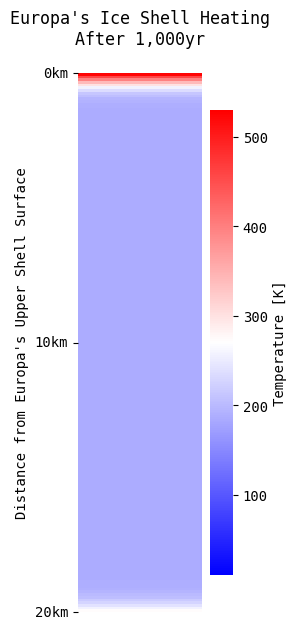

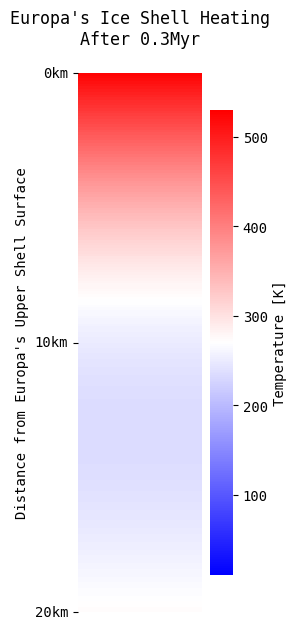

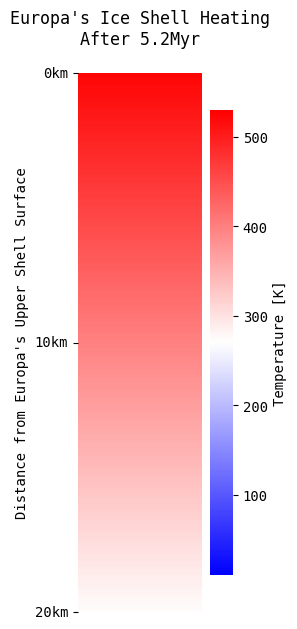

In [3]:
T1_000, T = T_shell_fixed(2.5e-6 * (60*60*24*365), 524, 1_000)
T100_000, T_ = T_shell_fixed(2.5e-6 * (60*60*24*365), 524, 300_000)
T2_000_000, Tend_ = T_shell_fixed(2.5e-6 * (60*60*24*365), 524, 5_200_000)
#####



fig, ax = plt.subplots(figsize=(2, 7))

ax = sns.heatmap(T1_000, cmap = 'bwr',
                cbar_kws={'label': 'Temperature [K]'}, vmin = 10, vmax = 530)
ax.set_array = T1_000


y_tick_labels = [0, 10, 20]
step = 0.1 
y_tick_position = [val/step for val in y_tick_labels]
yLabels = ["0km", "10km", "20km"]

ax.set_yticks(y_tick_position)
ax.set_yticklabels(yLabels, rotation = 0)
ax.set_ylabel("Distance from Europa's Upper Shell Surface")
ax.set_title("Europa's Ice Shell Heating\nAfter 1,000yr\n")
ax.set(xticklabels=[])
ax.set(xlabel=None)
ax.tick_params(bottom=False)
#plt.savefig(fname = "1,000yr Heating 475K", dpi = 600, bbox_inches = "tight")

plt.show()

###

fig, ax = plt.subplots(figsize=(2, 7))


ax = sns.heatmap(T100_000, cmap = 'bwr',
                cbar_kws={'label': 'Temperature [K]'}, vmin = 10, vmax = 530)
ax.set_array = T100_000


y_tick_labels = [0, 10, 20]
step = 0.1 
y_tick_position = [val/step for val in y_tick_labels]
yLabels = ["0km", "10km", "20km"]

ax.set_yticks(y_tick_position)
ax.set_yticklabels(yLabels, rotation = 0)
ax.set_ylabel("Distance from Europa's Upper Shell Surface")
ax.set_title("Europa's Ice Shell Heating\nAfter 0.3Myr\n")
ax.set(xticklabels=[])
ax.set(xlabel=None)
ax.tick_params(bottom=False)
#plt.savefig(fname = "0,3Myr Heating 475K", dpi = 600, bbox_inches = "tight")

plt.show()

###

fig, ax2 = plt.subplots(figsize=(2, 7))


ax2 = sns.heatmap(T2_000_000, cmap = 'bwr',
                cbar_kws={'label': 'Temperature [K]'}, vmin = 10, vmax = 530)
ax.set_array = T2_000_000


y_tick_labels = [0, 10, 20]
step = 0.1 
y_tick_position = [val/step for val in y_tick_labels]
yLabels = ["0km", "10km", "20km"]

ax2.set_yticks(y_tick_position)
ax2.set_yticklabels(yLabels, rotation = 0)
ax2.set_ylabel("Distance from Europa's Upper Shell Surface")
ax2.set_title("Europa's Ice Shell Heating\nAfter 5.2Myr\n")
ax2.set(xticklabels=[])
ax2.set(xlabel=None)
ax2.tick_params(bottom=False)
#plt.savefig(fname = "5,2Myr Heating 475K", dpi = 600, bbox_inches = "tight")

plt.show()

In [1]:
# Thermal Diffusivity
l = 20_000
D = 2.5e-6
tau = (l**2/D)/(3600*24*365*1e6)

print(tau, "Myr for diffusion time")

5.073566717402334 Myr for diffusion time


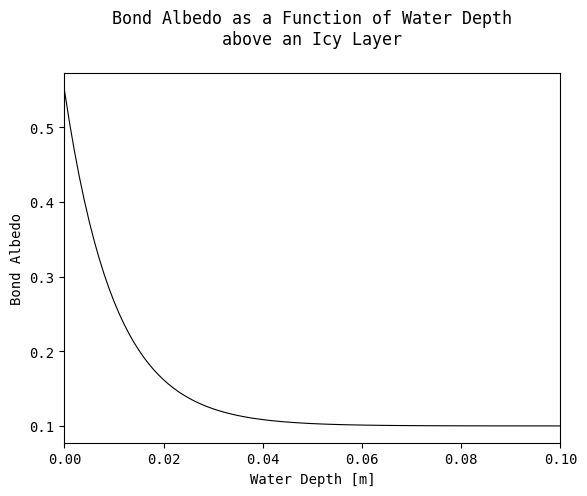

In [6]:
# Just coding up some albedo stuff
Aw = 0.1
Aice = 0.55
l = [i/1000 for i in range(101)]

Albedo_change = []

for i in range(len(l)):
    A_tot = Aw + (Aice - Aw) * np.exp(-2*l[i]*49.64)
    Albedo_change.append(A_tot)

#Albedo changes right when it starts melting

plt.plot(l, Albedo_change, color = 'black', linewidth = 0.8)
plt.title("Bond Albedo as a Function of Water Depth\nabove an Icy Layer\n")
plt.xlabel("Water Depth [m]")
plt.ylabel("Bond Albedo")
plt.xlim(0,0.1)
#plt.savefig(fname = "Albedo", dpi = 600, bbox_inches = "tight")

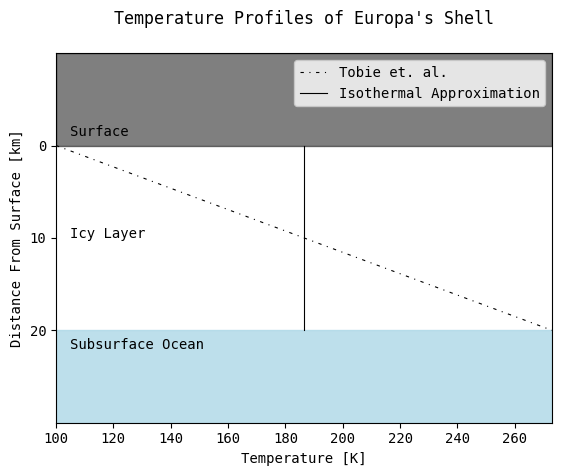

In [5]:
# Thermal Profile for Shell, (a) as in paper, (b) isotherm


surface_distance = [20, 0] #y
temperatures = [100, 273] #x

y_labels = [20, 10, 0]
y_position = [0, 10, 20]

plt.plot(temperatures, surface_distance, linewidth = 0.8, color = "black", linestyle = (0, (3, 5, 1, 5)), label = "Tobie et. al.")
plt.yticks(y_position, y_labels)
plt.axhspan(-10,0, color = "lightblue", alpha = 0.8)
plt.axhspan(20,30, color = "black", alpha = 0.5)
plt.axvline(186.5, 0.25,0.75, color = "black", linewidth = 0.8, label = "Isothermal Approximation")
plt.text(105, -2, "Subsurface Ocean")
plt.text(105, 10, "Icy Layer")
plt.text(105, 21, "Surface")
plt.xlim(100, 273)
plt.ylim(-10,30)
plt.xlabel("Temperature [K]")
plt.ylabel("Distance From Surface [km]")
plt.title("Temperature Profiles of Europa's Shell\n")
plt.legend()
#plt.savefig(fname = "Temperature Profiles", dpi = 600, bbox_inches = "tight")
plt.show()